<div style="background:#FFF5F8;border:3px solid #E0218A;border-radius:16px;padding:28px;text-align:center;">
<h1 style="color:#E0218A;margin:0;">🐥 Curso de Machine Learning · Clase 5 de 7</h1>
<h2 style="color:#1B2A5B;margin:10px 0 4px;">Clasificación, ¿quién caerá en mora? Cada error cuesta soles</h2>
<p style="color:#1B2A5B;margin:6px 0;">Con la Miss Yera · <a href="https://missyera.com">missyera.com</a> · @soymissyera</p>
<p style="color:#E0218A;margin:0;"><b>Regla de oro del curso, nadie ejecuta una celda sin predecir en voz alta qué va a pasar.</b></p>
</div>

## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥🐥🐥🐥🐥▫️▫️ · clase 5 de 7

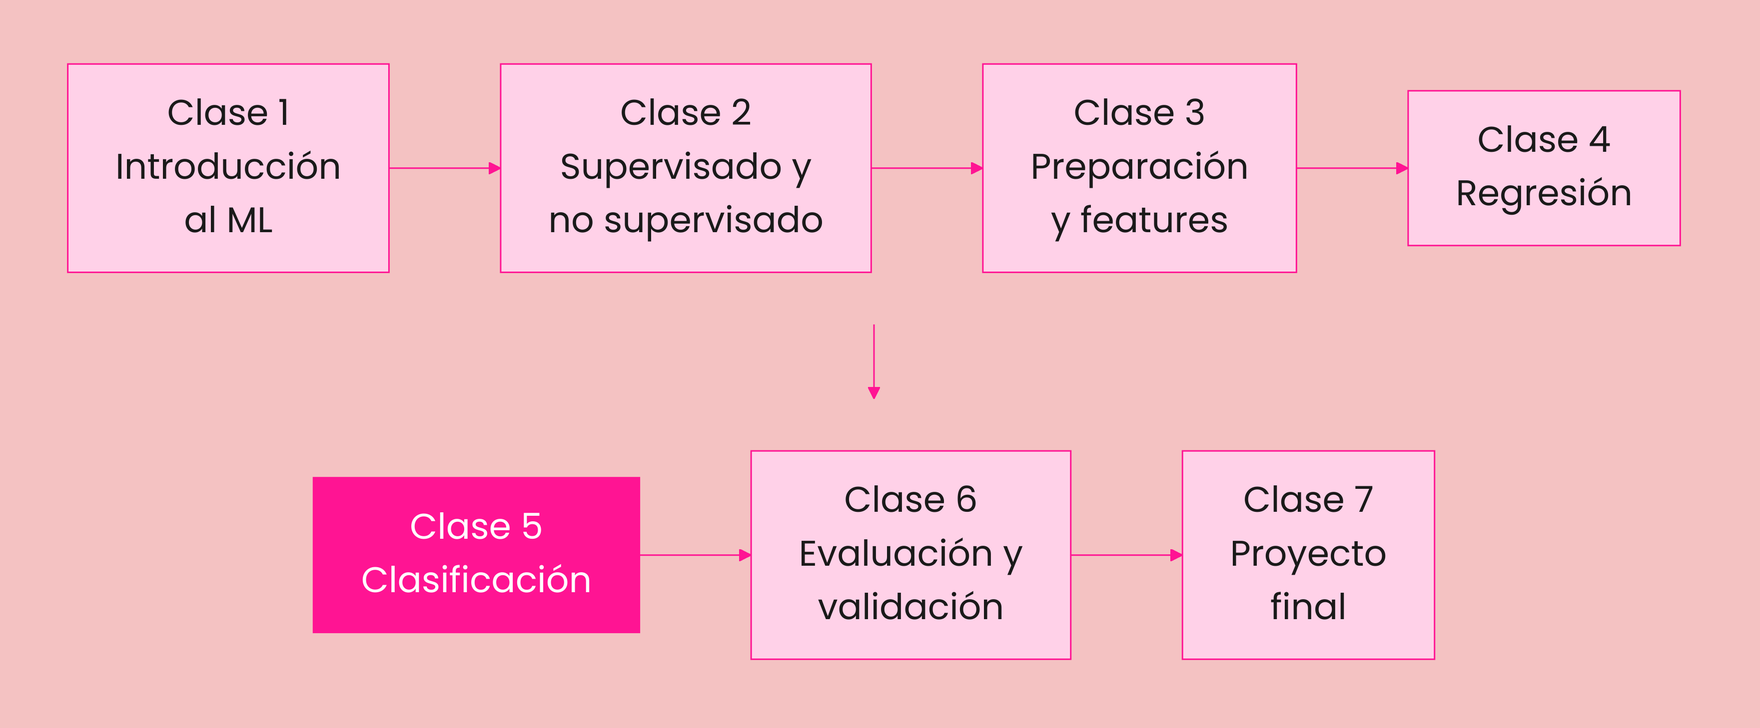


## 🔁 Antes de arrancar, 60 segundos de la clase anterior

En la clase 4, regresión, ¿qué línea de crédito darle a cada bodega?, dejamos lista la base para lo de hoy. Si algo de lo que sigue no te suena, regresa a ese notebook o al video de la clase 4 de la playlist antes de continuar.


In [1]:
#@title 🎬 Toca play · Quiz de entrada, ¿qué te llevaste de la clase anterior?
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de entrada, ¿qué te llevaste de la clase anterior?</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. ¿Cuál es la receta universal de scikit-learn?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin5_0" value="0"> Crear, entrenar, predecir, evaluar</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin5_0" value="1"> Descargar, copiar, pegar, rezar</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin5_0" value="2"> Limpiar, graficar, imprimir, guardar</label><div id="qin5_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Qué te dice el MAE de la línea de crédito?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin5_1" value="0"> El porcentaje de aciertos</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin5_1" value="1"> En promedio cuántos soles se equivoca el modelo</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin5_1" value="2"> Cuántas bodegas hay en el dataset</label><div id="qin5_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[0, "cuatro pasos, siempre los mismos"], [1, "es la m\u00e9trica que se lee en soles"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qin5_"+i+"\']:checked");
        var fb=document.getElementById("qin5_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🎯 Lo que vas a lograr hoy

- Entrenar dos rivales, la regresión logística y el bosque, para predecir la mora.
- Armar la matriz de confusión primero a mano y ponerle soles a cada tipo de error.
- Mover la perilla del umbral y entender que esa decisión es del negocio, no del modelo.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><i>"La mora se está comiendo el margen. Quiero saber quién va a caer ANTES de que caiga. Y ojo, rechazar a un buen cliente también cuesta, se va a la competencia."</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>



<div style="background: linear-gradient(135deg, #FF1493 0%, #FF69B4 55%, #FFB6C1 100%); border-radius: 22px; padding: 42px 36px; text-align: center; color: white; font-family: 'Inter', sans-serif;">
  <div style="font-size: 15px; letter-spacing: 3px; opacity: .95;">🐤 CURSO DE MACHINE LEARNING · CLASE 05</div>
  <h1 style="margin: 14px 0 6px 0; font-size: 40px; color: white;">Clasificación con scikit-learn</h1>
  <div style="font-size: 18px; opacity: .96;">Predecir categorías y mirar de frente a la matriz de confusión</div>
  <div style="margin-top: 22px; font-size: 14px; background: rgba(255,255,255,.18); display: inline-block; padding: 8px 20px; border-radius: 999px;">Miss Yera · missyera.com · @soymissyera</div>
</div>



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 17px;">🎯 Al final de esta clase vas a poder</b>
<ul style="margin-top: 10px;"><li>Entrenar una regresión logística y un bosque para clasificar</li>
<li>Construir y leer la matriz de confusión a mano y con sklearn</li>
<li>Calcular accuracy, precisión, recall y F1 sabiendo cuándo usar cada una</li>
<li>Trabajar con probabilidades y mover el umbral de decisión</li>
<li>Elegir la métrica correcta según el costo del error</li></ul>
</div>


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')

Setup listo, pollito 🐥


## 1. La misión, predecir la mora de clientes de PolliCreditos

Un PolliCreditos pierde clientes cada mes. Si predecimos quién está por irse, el equipo de retención lo llama antes. El target es una categoría, cae en mora o se queda, terreno de la clasificación.

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 600

df = pd.DataFrame({
    "pagos_puntuales": np.random.poisson(8, n),
    "meses_antiguedad": np.random.randint(1, 48, n),
    "productos_activos": np.random.poisson(2, n),
    "atrasos_previos": np.random.poisson(0.4, n),
})

# La mora depende de poco uso, poca antigüedad y atrasos_previos, con ruido calibrado
puntaje = (-0.35 * df["pagos_puntuales"] - 0.06 * df["meses_antiguedad"]
           - 0.4 * df["productos_activos"] + 1.1 * df["atrasos_previos"]
           + np.random.normal(0, 1.6, n) + 3.2)
df["cae_en_mora"] = (puntaje > 0).astype(int)

print(f"Tasa de mora, {df['cae_en_mora'].mean():.1%}")
df.head()

Tasa de mora, 25.8%


,pagos_puntuales,meses_antiguedad,productos_activos,atrasos_previos,cae_en_mora
0,6,6,2,1,0
1,7,1,2,1,1
2,6,7,3,3,1
3,7,27,1,2,1
4,7,21,3,0,0


## 2. Entrenamos dos rivales, logística y bosque

### 🧮 La matemática detrás · Probabilidad, la sigmoide

$\sigma(z) = \dfrac{1}{1 + e^{-z}}$

**Lectura en palabras,** la sigmoide aplasta cualquier número a un valor entre 0 y 1, por eso la logística te entrega probabilidades y no veredictos secos.

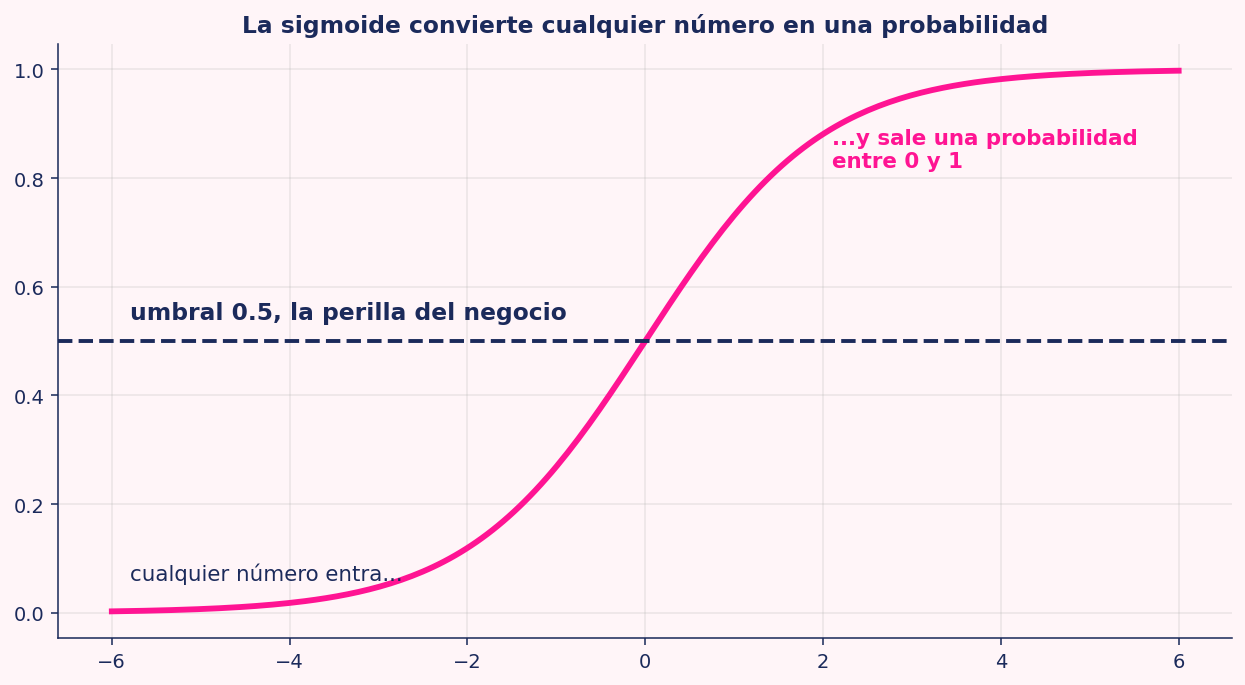

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;">🤔 <b>Por qué te sirve saberlo,</b> La matriz de confusión que vas a armar a mano es probabilidad condicional pura, de los que el modelo acusó, cuántos eran culpables.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df[["pagos_puntuales", "meses_antiguedad", "productos_activos", "atrasos_previos"]]
y = df["cae_en_mora"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# La logística va en pipeline con escalado, los modelos de distancia y gradiente lo agradecen
logistica = Pipeline([("escala", StandardScaler()),
                      ("modelo", LogisticRegression(random_state=42))])
logistica.fit(X_train, y_train)

bosque = RandomForestClassifier(n_estimators=200, random_state=42)
bosque.fit(X_train, y_train)

print(f"Accuracy logística, {logistica.score(X_test, y_test):.3f}")
print(f"Accuracy bosque,    {bosque.score(X_test, y_test):.3f}")

Accuracy logística, 0.806
Accuracy bosque,    0.739



<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Por qué la logística va con escalador y el bosque no?</b><br>
La logística optimiza con gradiente y las variables en escalas distintas la marean. El bosque solo hace cortes de tipo mayor o menor que, y esos cortes no cambian al escalar. Por eso el pipeline escala para la logística y el bosque va directo.
</div>


## 3. La matriz de confusión, primero a mano

Antes de la función de sklearn, la construimos a mano para que nunca más te confunda.

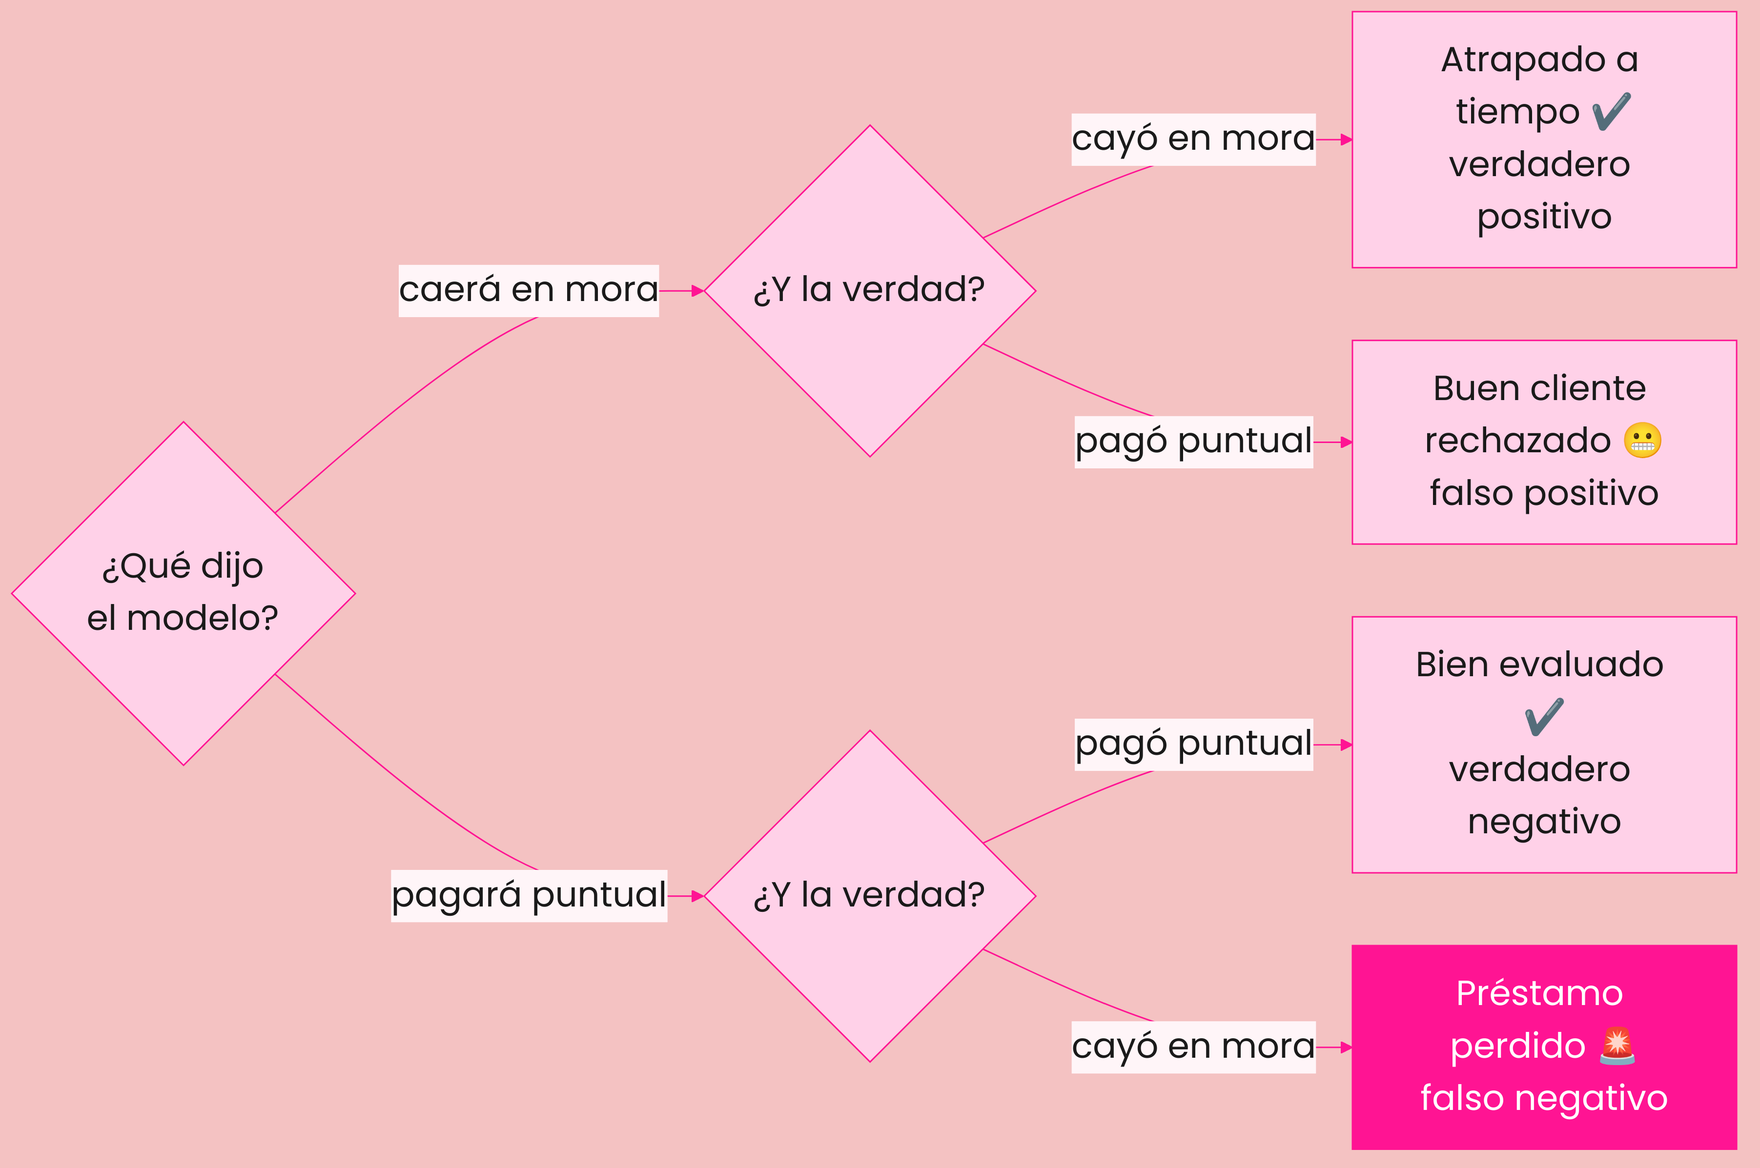

*Cada predicción cae en uno de cuatro cuadrantes, y el más caro es el falso negativo, el préstamo perdido.*


In [5]:
pred = bosque.predict(X_test)

vp = ((pred == 1) & (y_test == 1)).sum()   # verdadero positivo, dijimos mora y era mora
vn = ((pred == 0) & (y_test == 0)).sum()   # verdadero negativo, dijimos queda y se quedó
fp = ((pred == 1) & (y_test == 0)).sum()   # falso positivo, alarma innecesaria
fn = ((pred == 0) & (y_test == 1)).sum()   # falso negativo, mora que se nos escapó

print(f"""
                     REALIDAD
                  Mora      Queda
PREDICHO  Mora    {vp:3d} VP    {fp:3d} FP   ← alarmas
          Queda   {fn:3d} FN    {vn:3d} VN   ← silencios

VP y VN son aciertos. FP es llamar a quien no se iba a ir.
FN es el más caro aquí, el cliente que cayó en mora sin que lo detectáramos.
""")


                     REALIDAD
                  Mora      Queda
PREDICHO  Mora     15 VP     16 FP   ← alarmas
          Queda    31 FN    118 VN   ← silencios

VP y VN son aciertos. FP es llamar a quien no se iba a ir.
FN es el más caro aquí, el cliente que cayó en mora sin que lo detectáramos.



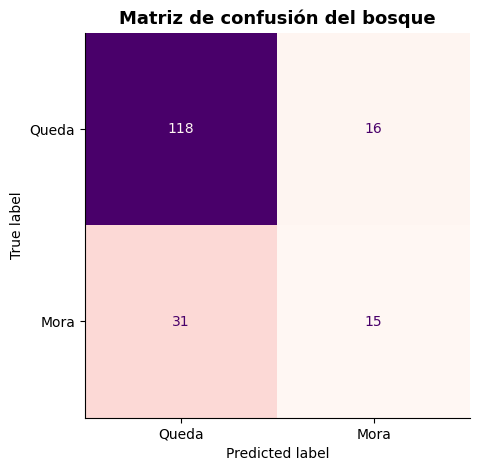

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_estimator(bosque, X_test, y_test,
    display_labels=["Queda", "Mora"], cmap="RdPu", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión del bosque")
ax.grid(False)
plt.show()

## 4. El boletín de notas completo

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

metricas = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
}
for nombre, valor in metricas.items():
    print(f"{nombre:10s} {valor:.3f}")

print("\n", classification_report(y_test, pred, target_names=["Queda", "Mora"]))

accuracy   0.739
precision  0.484
recall     0.326
f1         0.390

               precision    recall  f1-score   support

       Queda       0.79      0.88      0.83       134
        Mora       0.48      0.33      0.39        46

    accuracy                           0.74       180
   macro avg       0.64      0.60      0.61       180
weighted avg       0.71      0.74      0.72       180




<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 El significado de cada nota</b><br>
Accuracy, de todo lo que dije, cuánto acerté, engañosa con clases desbalanceadas. Precisión, de mis alarmas de mora, cuántas eran reales, importa cuando la alarma falsa cuesta. Recall, de las moras reales, cuántas detecté, importa cuando dejar pasar una cuesta. F1, el equilibrio entre precisión y recall en un solo número.
</div>


## 5. Probabilidades y el umbral, la perilla secreta

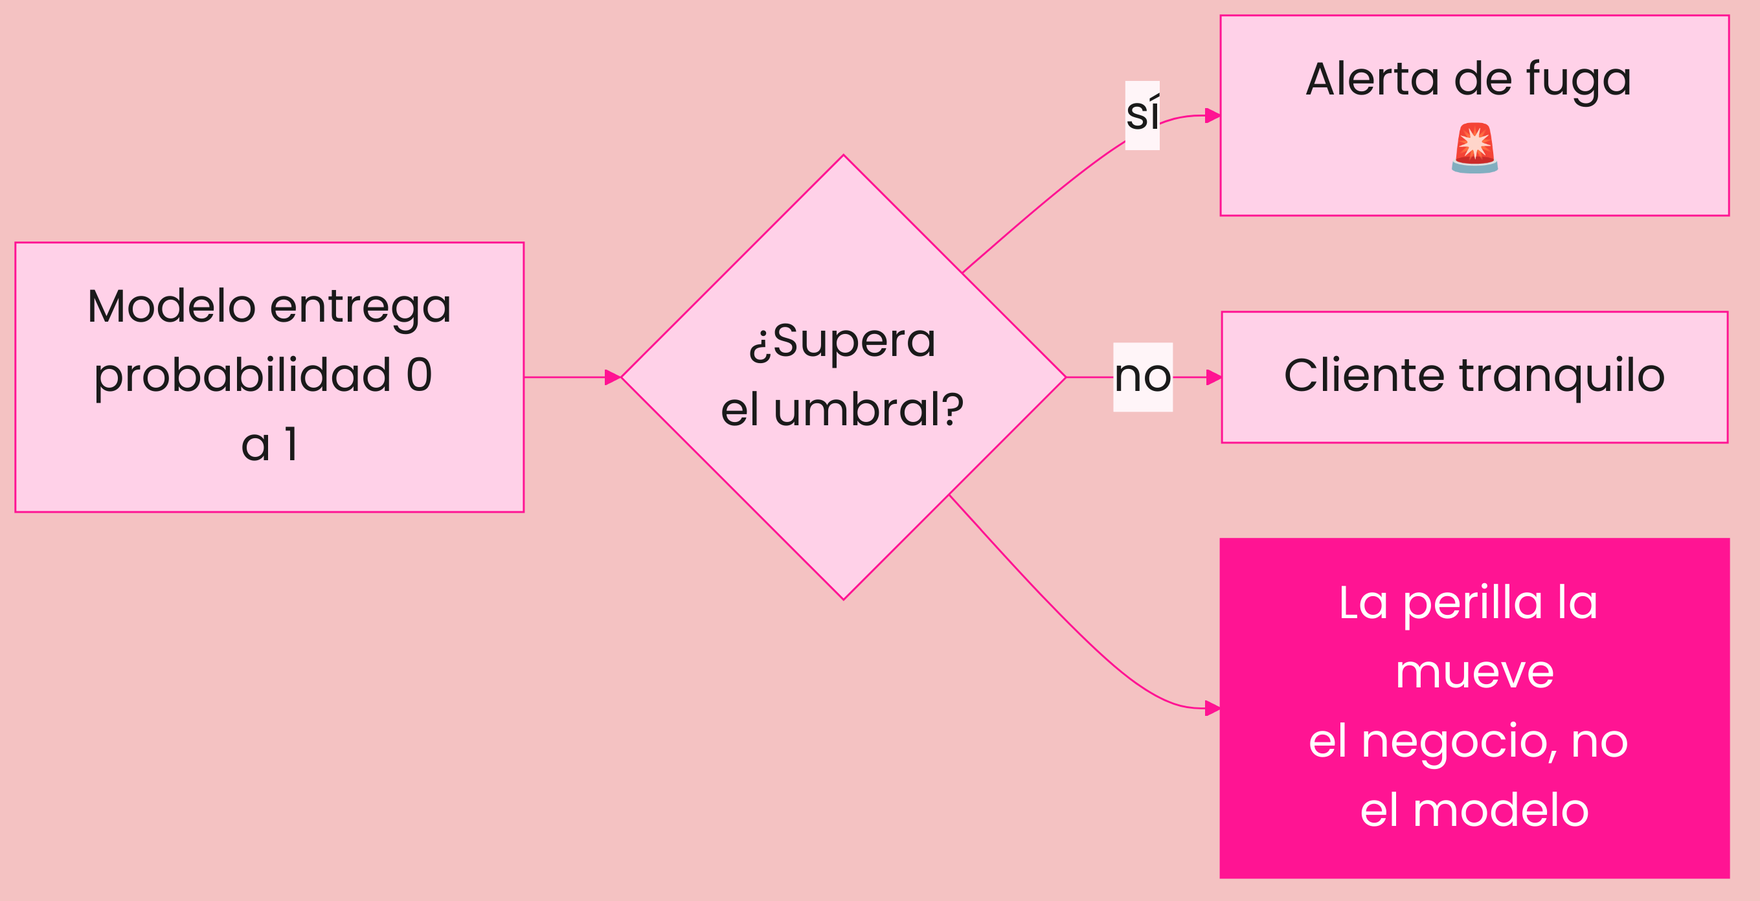

*El modelo entrega una probabilidad, el umbral la convierte en decisión, y esa perilla la mueve el negocio.*


In [8]:
probabilidades = bosque.predict_proba(X_test)[:, 1]

print("Cinco clientes con su probabilidad de mora,")
for i in range(5):
    barra = "█" * int(probabilidades[i] * 20)
    print(f"  Cliente {i+1}, {probabilidades[i]:.2f} {barra}")

# Movemos el umbral y vemos el trade off
print("\nUmbral   Precisión  Recall   ¿Qué pasa?")
for umbral in [0.3, 0.5, 0.7]:
    pred_u = (probabilidades >= umbral).astype(int)
    p = precision_score(y_test, pred_u)
    r = recall_score(y_test, pred_u)
    nota = "más alarmas, cazamos más moras" if umbral == 0.3 else ("equilibrio estándar" if umbral == 0.5 else "solo alarmas seguras, se escapan moras")
    print(f"  {umbral:.1f}      {p:.3f}     {r:.3f}   {nota}")

Cinco clientes con su probabilidad de mora,
  Cliente 1, 0.94 ██████████████████
  Cliente 2, 0.09 █
  Cliente 3, 0.57 ███████████
  Cliente 4, 0.40 ███████
  Cliente 5, 0.26 █████

Umbral   Precisión  Recall   ¿Qué pasa?
  0.3      0.478     0.696   más alarmas, cazamos más moras
  0.5      0.500     0.348   equilibrio estándar
  0.7      0.533     0.174   solo alarmas seguras, se escapan moras



<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués del umbral</b><br>
El modelo no dice mora o queda, dice probabilidad, y el umbral la convierte en decisión. Bajar el umbral caza más moras a costa de más llamadas innecesarias, subirlo hace lo contrario. El umbral correcto no lo decide la estadística, lo decide el costo de cada error en tu negocio.
</div>


## 6. ¿Qué variables delatan la mora?

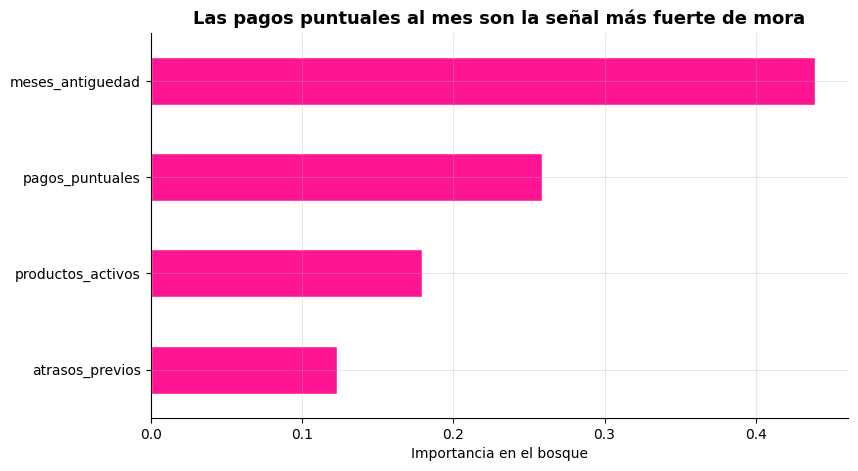

Insight de negocio, un cliente que deja de pagar puntual ya empezó a irse,
el sistema de retención debería activarse por caída de pagos puntuales


In [9]:
importancias = pd.Series(bosque.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots()
importancias.plot(kind="barh", color=YERA[0], edgecolor="white", ax=ax)
ax.set_title("Las pagos puntuales al mes son la señal más fuerte de mora")
ax.set_xlabel("Importancia en el bosque")
plt.show()
print("Insight de negocio, un cliente que deja de pagar puntual ya empezó a irse,")
print("el sistema de retención debería activarse por caída de pagos puntuales")

## 7. Reto resuelto, el sistema de alertas de retención

El reto pedía un sistema que reciba la data de los clientes y devuelva la lista priorizada para el equipo de retención, con nivel de riesgo. Solución completa.

In [10]:
# Solución del reto
def generar_alertas(datos_clientes: pd.DataFrame, umbral_alto: float = 0.7,
                    umbral_medio: float = 0.4) -> pd.DataFrame:
    """Prioriza clientes por probabilidad de mora con niveles de riesgo."""
    resultado = datos_clientes.copy()
    resultado["prob_mora"] = bosque.predict_proba(datos_clientes[X.columns])[:, 1]
    resultado["riesgo"] = pd.cut(resultado["prob_mora"],
                                 bins=[-0.01, umbral_medio, umbral_alto, 1.01],
                                 labels=["🟢 bajo", "🟡 medio", "🔴 alto"])
    return resultado.sort_values("prob_mora", ascending=False)


alertas = generar_alertas(X_test.head(10))
print(alertas[["pagos_puntuales", "atrasos_previos", "prob_mora", "riesgo"]].round(2).to_string())

conteo = alertas["riesgo"].value_counts()
print(f"\nResumen para el equipo, {conteo.get('🔴 alto', 0)} llamadas urgentes esta semana")
assert alertas["prob_mora"].is_monotonic_decreasing
print("✅ Lista verificada, ordenada de mayor a menor riesgo")

     pagos_puntuales  atrasos_previos  prob_mora   riesgo
349                2                0       0.94   🔴 alto
248                4                1       0.57  🟡 medio
377                6                2       0.40   🟢 bajo
556                9                0       0.32   🟢 bajo
293                4                0       0.26   🟢 bajo
126                9                0       0.16   🟢 bajo
49                 6                0       0.14   🟢 bajo
71                 7                0       0.09   🟢 bajo
367                5                0       0.02   🟢 bajo
346               10                0       0.00   🟢 bajo

Resumen para el equipo, 1 llamadas urgentes esta semana
✅ Lista verificada, ordenada de mayor a menor riesgo



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Qué es un falso negativo en el caso de PolliCreditos?</b><ol type='a'><li>Una alarma innecesaria</li>
<li>✅ <b>Una mora que el modelo no detectó</b></li>
<li>Un acierto</li>
<li>Un cliente nuevo</li></ol><i>💡 Dijimos que se quedaba y se fue, el error más caro aquí.</i><br>
<b>2. ¿Cuándo la accuracy engaña?</b><ol type='a'><li>Siempre</li>
<li>✅ <b>Con clases desbalanceadas</b></li>
<li>Con datos limpios</li>
<li>Nunca</li></ol><i>💡 Con 95% de una clase, predecir siempre esa clase da 95% de accuracy sin servir de nada.</i><br>
<b>3. ¿Qué controla el umbral de decisión?</b><ol type='a'><li>La velocidad del modelo</li>
<li>✅ <b>El balance entre precisión y recall</b></li>
<li>El número de features</li>
<li>El tamaño del test</li></ol><i>💡 Es la perilla que convierte probabilidades en decisiones.</i><br>
<b>4. Si dejar pasar una mora cuesta carísimo, priorizo...</b><ol type='a'><li>Precisión</li>
<li>✅ <b>Recall</b></li>
<li>Accuracy</li>
<li>El intercepto</li></ol><i>💡 Recall alto significa cazar la mayor cantidad de moras reales.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>La matriz de confusión desarma los aciertos y errores en cuatro casillas</li>
<li>Precisión cuida las alarmas falsas, recall cuida las moras perdidas</li>
<li>El umbral es la perilla de negocio sobre las probabilidades</li>
<li>La importancia de features convierte el modelo en insights accionables</li></ul>
<b>📝 Tarea de la semana,</b> entrena un clasificador de churn con un dataset real de telecomunicaciones de Kaggle y decide el umbral justificando el costo de cada error.<br><b>➡️ Próxima clase,</b> evaluación y validación, el arte de no mentirte a ti misma con las métricas.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
print(f'Accuracy {acc:.0%}, el modelo de mora es excelente')
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">Con 95% de clientes que pagan puntual, un modelo que diga siempre paga puntual saca 95% de accuracy sin detectar UNA sola mora. En clases desbalanceadas el accuracy engaña, aquí mandan precisión y recall.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [11]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. De todas las alarmas de mora que sonó el modelo, cuántas eran verdad, eso es...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_0" value="0"> Recall</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_0" value="1"> Precisión</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_0" value="2"> Accuracy</label><div id="qout5_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. Bajar el umbral de 0.5 a 0.3 hace que el modelo...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_1" value="0"> Suene más alarmas, atrape más moras y moleste a más buenos clientes</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_1" value="1"> Suene menos alarmas</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_1" value="2"> No cambie nada</label><div id="qout5_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. ¿Por qué el falso negativo es el error más caro en PolliCreditos?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_2" value="0"> Porque molesta al cliente con llamadas</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_2" value="1"> Porque es un préstamo que se pierde completo</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout5_2" value="2"> Porque baja el accuracy</label><div id="qout5_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "precisi\u00f3n mira las alarmas, recall mira las moras reales"], [0, "la perilla mueve el trade-off completo"], [1, "ponle soles a cada cuadrante de la matriz"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout5_"+i+"\']:checked");
        var fb=document.getElementById("qout5_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

In [12]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **Matriz de confusión** | la tabla de aciertos y errores del clasificador en sus cuatro combinaciones |
| **Precisión** | de todas las alarmas de mora que soné, cuántas eran verdad |
| **Recall** | de todos los que cayeron en mora, a cuántos atrapé a tiempo |
| **F1** | el equilibrio entre precisión y recall en un solo número |
| **Umbral** | el punto de corte que convierte una probabilidad en decisión, 0.5 es solo el default |
| **Falso negativo** | el préstamo perdido, el cliente que cayó en mora sin alerta, el error más caro de la cartera |

Este glosario se acumula clase a clase, en el proyecto final te llevas el diccionario completo del curso.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

En la clase 6 viene overfitting en vivo, la auditoría del regulador. Te espero en el siguiente video de la playlist.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>
